In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import random as random
import xgi as xgi
import networkx as nx
import random
from collections import defaultdict
from Overlap_func import*
from Configurational_model_HO import*
from HO_effective_degree import *

In [2]:
import numpy as np
from numba import jit, types
from numba.typed import List

@jit(nopython=True)
def _gillespie_core(N, beta1, beta2, mu, edges_array, triangles_array, 
                   init_infec_array, t_max, check_interval=200, variance_threshold=1e-5):
    """
    Core Gillespie simulation optimized with Numba.
    All list operations moved to pre-allocated arrays for speed.
    """
    # Initialize state arrays
    Infected = np.zeros(N, dtype=np.int32)
    InfectionSource = np.zeros(N, dtype=np.int32)  # 0: none, 5: edge, 10: hyperedge
    
    # Set initial infections
    for i in range(len(init_infec_array)):
        Infected[init_infec_array[i]] = 1
    
    # Pre-allocate result arrays (estimate max events)
    max_events = min(1000000, int(t_max * N * 10))  # Conservative estimate
    times = np.zeros(max_events)
    I = np.zeros(max_events, dtype=np.int32)
    I_links = np.zeros(max_events, dtype=np.int32)
    I_hyperedges = np.zeros(max_events, dtype=np.int32)
    times_links = np.zeros(max_events)
    times_hyperedges = np.zeros(max_events)
    
    # Initialize counters
    event_count = 0
    link_event_count = 0
    hyperedge_event_count = 0
    current_link_infections = 0
    current_hyperedge_infections = 0
    
    # Initial state
    times[0] = 0.0
    I[0] = np.sum(Infected)
    I_links[0] = 0
    I_hyperedges[0] = 0
    times_links[0] = 0.0
    times_hyperedges[0] = 0.0
    event_count = 1
    link_event_count = 1
    hyperedge_event_count = 1
    
    # Pre-allocate rate arrays
    rate_vec = np.zeros(N)
    edge_rate = np.zeros(N)
    hyperedge_rate = np.zeros(N)
    
    t = 0.0
    while t < t_max and event_count < max_events:
        # Reset rates
        rate_vec[:] = 0
        edge_rate[:] = 0
        hyperedge_rate[:] = 0
        
        # Pairwise transmission - vectorized where possible
        for edge_idx in range(edges_array.shape[0]):
            v1 = edges_array[edge_idx, 0]
            v2 = edges_array[edge_idx, 1]
            
            if Infected[v1] == 0 and Infected[v2] == 1:
                rate_vec[v1] += beta1
                edge_rate[v1] += beta1
            elif Infected[v2] == 0 and Infected[v1] == 1:
                rate_vec[v2] += beta1
                edge_rate[v2] += beta1
        
        # Triangle-based transmission
        for tri_idx in range(triangles_array.shape[0]):
            n1 = triangles_array[tri_idx, 0]
            n2 = triangles_array[tri_idx, 1]
            n3 = triangles_array[tri_idx, 2]
            
            # Check all three possible infection scenarios
            if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                rate_vec[n1] += beta2
                hyperedge_rate[n1] += beta2
            elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                rate_vec[n2] += beta2
                hyperedge_rate[n2] += beta2
            elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                rate_vec[n3] += beta2
                hyperedge_rate[n3] += beta2
        
        # Recovery for infected nodes - vectorized
        for i in range(N):
            if Infected[i] == 1:
                rate_vec[i] += mu
        
        total_rate = np.sum(rate_vec)
        if total_rate == 0:
            break
        
        # Generate random numbers using Numba-compatible approach
        delay = -np.log(np.random.random()) / total_rate
        t += delay
        
        # Event selection using cumulative distribution
        rr = np.random.random() * total_rate
        cumulative = 0.0
        selected_node = -1
        
        for i in range(N):
            cumulative += rate_vec[i]
            if rr < cumulative:
                selected_node = i
                break
        
        if selected_node == -1:  # Fallback
            continue
            
        if Infected[selected_node] == 1:
            # Recovery event
            if InfectionSource[selected_node] == 5:
                current_link_infections -= 1
            elif InfectionSource[selected_node] == 10:
                current_hyperedge_infections -= 1
            Infected[selected_node] = 0
            InfectionSource[selected_node] = 0
        else:
            # Infection event
            Infected[selected_node] = 1
            
            # Determine infection source
            if edge_rate[selected_node] > 0 and hyperedge_rate[selected_node] > 0:
                # Both sources possible
                if np.random.random() < edge_rate[selected_node] / rate_vec[selected_node]:
                    InfectionSource[selected_node] = 5
                    current_link_infections += 1
                    if link_event_count < max_events:
                        times_links[link_event_count] = t
                        link_event_count += 1
                else:
                    InfectionSource[selected_node] = 10
                    current_hyperedge_infections += 1
                    if hyperedge_event_count < max_events:
                        times_hyperedges[hyperedge_event_count] = t
                        hyperedge_event_count += 1
            elif edge_rate[selected_node] > 0:
                InfectionSource[selected_node] = 5
                current_link_infections += 1
                if link_event_count < max_events:
                    times_links[link_event_count] = t
                    link_event_count += 1
            else:
                InfectionSource[selected_node] = 10
                current_hyperedge_infections += 1
                if hyperedge_event_count < max_events:
                    times_hyperedges[hyperedge_event_count] = t
                    hyperedge_event_count += 1
        
        # Log data
        if event_count < max_events:
            times[event_count] = t
            I[event_count] = np.sum(Infected)
            I_links[event_count] = current_link_infections
            I_hyperedges[event_count] = current_hyperedge_infections
            event_count += 1
        
        # Variance-based stopping condition
        if event_count > check_interval:
            # Calculate variance of recent values
            variance_sum = 0.0
            mean_val = 0.0
            
            # Calculate mean
            for i in range(check_interval):
                mean_val += I[event_count - 1 - i] / N
            mean_val /= check_interval
            
            # Calculate variance
            for i in range(check_interval):
                diff = (I[event_count - 1 - i] / N) - mean_val
                variance_sum += diff * diff
            variance = variance_sum / check_interval
            
            if variance < variance_threshold:
                break
    
    return (times[:event_count], I[:event_count], 
            I_links[:event_count], I_hyperedges[:event_count],
            times_links[:link_event_count], times_hyperedges[:hyperedge_event_count])


def SIS_gillespie_HO(N, beta1, beta2, mu, edges, triangles, init_infec, t_max,
                     check_interval=200, variance_threshold=1e-5, seed=None):
    """
    Optimized Stochastic SIS Gillespie simulation on a hypergraph with Numba JIT compilation.
    
    This version converts Python lists to NumPy arrays for Numba compatibility and 
    uses pre-allocated arrays to minimize memory allocations during simulation.
    
    Parameters and returns are the same as the original function.
    """
    
    # Set random seed
    if seed is not None:
        np.random.seed(seed)
    
    # Convert inputs to Numba-compatible formats
    edges_array = np.array(edges, dtype=np.int32)
    triangles_array = np.array(triangles, dtype=np.int32)
    init_infec_array = np.array(init_infec, dtype=np.int32)
    
    # Call the JIT-compiled core function
    (times_result, I_result, I_links_result, 
     I_hyperedges_result, times_links_result, 
     times_hyperedges_result) = _gillespie_core(
        N, beta1, beta2, mu, edges_array, triangles_array, 
        init_infec_array, t_max, check_interval, variance_threshold
    )
    
    #print(f"Simulation ended at time t = {times_result[-1]:.2f}")
    
    # Convert back to lists for compatibility with original interface
    return (I_result.tolist(), times_result.tolist(), 
            I_links_result.tolist(), I_hyperedges_result.tolist(),
            times_links_result.tolist(), times_hyperedges_result.tolist())


# Alternative version that returns NumPy arrays (often faster for downstream processing)
def SIS_gillespie_HO_arrays(N, beta1, beta2, mu, edges, triangles, init_infec, t_max,
                           check_interval=200, variance_threshold=1e-5, seed=None):
    """
    Same as SIS_gillespie_HO but returns NumPy arrays instead of lists.
    Use this version if you plan to do further numerical processing.
    """
    if seed is not None:
        np.random.seed(seed)
    
    edges_array = np.array(edges, dtype=np.int32)
    triangles_array = np.array(triangles, dtype=np.int32)
    init_infec_array = np.array(init_infec, dtype=np.int32)
    
    result = _gillespie_core(
        N, beta1, beta2, mu, edges_array, triangles_array, 
        init_infec_array, t_max, check_interval, variance_threshold
    )
    
    #print(f"Simulation ended at time t = {result[1][-1]:.2f}")
    return result


In [3]:

@njit
def compute_contributions(S_states, S_values, I_states, I_values, I_values_pairs, I_values_triples,
                             I_prob, Z_prob, b1, b2, gamma):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    dI_pair=np.zeros((len(I_values)))
    dI_triple=np.zeros((len(I_values)))
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = I_states[i, 0], I_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]

        I_m1_curr = I_values_pairs[i]
        I_m2_curr = I_values_triples[i]
        # Infection rate calculation
        dI_pair[i] =  b1 * I_prob * k1 *S_curr - gamma * I_m1_curr
        dI_triple[i] = b2 * Z_prob * k2 *S_curr - gamma * I_m2_curr

    return dI_pair, dI_triple




def odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=False):
    """
    Numba-optimized main simulation with maximum performance.
    
    This version uses:
    - JIT-compiled critical functions
    - Array-based data structures
    - Vectorized operations
    - Optimized memory access patterns
    - Parallel processing where applicable
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma) - model parameters
    hyper_edge_list : list
        Hyperedges defining the network structure
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_t, I_t, Motifs_time) - simulation results
    """
    #print("Starting Numba-optimized simulation...")
    
    # Parameter setup
    b1, b2, gamma = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Optimized degree calculation
    #print("Computing degrees with Numba optimization...")
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    
    # Ensure we have at least 3 orders (0, 1, 2) for compatibility
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup optimized initial conditions
    #print("Initializing optimized state tracking...")
    state_tracker, motifs_init = setup_initial_conditions_optimized(
        initial_infected, node_list, degree_node
    )
    
    SS_0, SI_0, SSS_0, SSI_0 = motifs_init
    #print('Adaptative time', adaptive_dt)
    # Pre-allocate all time series arrays for better performance
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    S_t = np.zeros(max_steps + 1)  
    I_t = np.zeros(max_steps + 1)
    SS_t = np.zeros(max_steps + 1)
    SI_t = np.zeros(max_steps + 1)
    II_t = np.zeros(max_steps + 1)
    SSS_t = np.zeros(max_steps + 1)
    SSI_t = np.zeros(max_steps + 1)
    SII_t = np.zeros(max_steps + 1)
    III_t = np.zeros(max_steps + 1)
    I_pair_total= np.zeros(max_steps + 1)
    I_triples_total= np.zeros(max_steps + 1)
    

    # Initialize first values
    S_total, I_total = state_tracker.get_total_populations()
    times[0] = 0.0
    S_t[0] = S_total
    I_t[0] = I_total
    SS_t[0] = SS_0
    SI_t[0] = SI_0
    II_t[0] = 0
    SSS_t[0] = SSS_0  
    SSI_t[0] = SSI_0
    SII_t[0] = 0
    III_t[0] = 0
    
    # Constants for motif conservation
    total_links = SS_0 + SI_0
    total_groups = SSS_0 + SSI_0
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    Ik1k2=[];Sk1k2=[];Ik1k2_states=[]
    #print("Starting optimized integration loop...")
    I_values=state_tracker.I_values.copy()
    I_values_pairs = np.zeros(len(I_values))
    I_values_triples = np.zeros(len(I_values))
    # Main integration loop with Numba optimization
    while current_time < T and step < max_steps - 1:
        
        # Calculate mathematical constants using optimized function
        A, B, C, D, E = state_tracker.calculate_constants()
        
        # Compute infection probabilities with safety checks
        I_prob = SI_t[step] / A if A > 1e-12 else 0.0
        Z_prob = SII_t[step] / B if B > 1e-12 else 0.0
        Y_prob = 2 * SSI_t[step] / B if B > 1e-12 else 0.0
        
        # Current motif values
        SI = SI_t[step]
        II = II_t[step]
        SSI = SSI_t[step]
        SII = SII_t[step]
        III = III_t[step]
        
        # Compute motif derivatives using Numba
        dSI, dII, dSSI, dSII, dIII = compute_motif_derivatives_numba(
            SI, II, SSI, SII, III, I_prob, Z_prob, Y_prob,
            b1, b2, gamma, C, D, E
        )
        
        # Compute degree-based population derivatives
        state_tracker.compute_derivatives(I_prob, Z_prob, b1, b2, gamma)
        x=state_tracker.I_values.copy()
        Ik1k2_states.append(state_tracker.states)
        Sk1k2.append(state_tracker.S_values)
        Ik1k2.append(x)
        # Adaptive timestep control

        dI_pair, dI_triple = compute_contributions(state_tracker.states, state_tracker.S_values, state_tracker.states, state_tracker.I_values, I_values_pairs,I_values_triples,
                             I_prob, Z_prob, b1, b2, gamma)
        
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba(
                state_tracker.S_values, state_tracker.I_values,
                state_tracker.dS_values, state_tracker.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker.update_populations(dt)


        I_values_pairs +=  dI_pair*dt
        I_values_triples +=  dI_triple*dt
        
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store results
        S_total, I_total = state_tracker.get_total_populations()
        times[step] = current_time
        S_t[step] = S_total
        I_t[step] = I_total

        I_pair_total[step] = np.sum(I_values_pairs)
        I_triples_total[step] = np.sum(I_values_triples)
        
        # Update motifs
        SI_t[step] = SI_t[step-1] + dt * dSI
        II_t[step] = II_t[step-1] + dt * dII
        SS_t[step] = total_links - II_t[step] - SI_t[step]
        
        SSI_t[step] = SSI_t[step-1] + dt * dSSI
        SII_t[step] = SII_t[step-1] + dt * dSII
        III_t[step] = III_t[step-1] + dt * dIII
        SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]
        
        # Progress reporting
        if progress_callback and step % 100 == 0:
            progress_callback(current_time / T * 100)
        elif progress_callback and step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.3f}, dt={dt:.6f}, step={step})")
        
        # Early termination
        if I_total < 1e-8:
            print("Infection died out, terminating early")
            break
        if I_total > N * 1.2:
            print("Numerical instability detected")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length].copy()
    S_t_final = S_t[:actual_length].copy()
    I_t_final = I_t[:actual_length].copy()
    I_pair_total_final = I_pair_total[:actual_length].copy()
    I_triples_total_final = I_triples_total[:actual_length].copy()
    Motifs_time = [
        SS_t[:actual_length].copy(),
        SI_t[:actual_length].copy(),
        II_t[:actual_length].copy(),
        SSS_t[:actual_length].copy(),
        SSI_t[:actual_length].copy(),
        SII_t[:actual_length].copy(),
        III_t[:actual_length].copy()
    ]
    
    #print(f"Numba-optimized integration completed in {step} steps")
    #print(f"Final populations: S={S_t_final[-1]:.1f}, I={I_t_final[-1]:.1f}")
    
    return times_final, S_t_final, I_t_final, Motifs_time, I_pair_total_final, I_triples_total_final


def odeint_compact_effective_degree_HO_optimized_Ik1k2(para, hyper_edge_list, N, 
                                                initial_infected=None, T=15, 
                                                steps_ode=2000, use_numba=True, 
                                                use_fast_derivatives=True, progress_callback=False):
    """
    Optimized wrapper with automatic Numba usage.
    
    This function automatically uses the Numba-optimized version for
    maximum performance while maintaining backward compatibility.
    """
    if use_numba:
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )
    else:
        # Fallback to original implementation if needed
        print("Warning: Numba optimization disabled, using slower implementation")
        # Could implement non-Numba fallback here
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )


def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var


def degree_per_node_list(hyperedges, nodes):
    """Optimized degree calculation with pre-allocated arrays"""
    max_order = max(len(edge) for edge in hyperedges)
    node_max = max(nodes)
    
    # Pre-allocate arrays instead of using defaultdicts
    degree_arrays = [np.zeros(node_max + 1, dtype=np.int32) for _ in range(max_order)]
    
    for edge in hyperedges:
        order_index = len(edge) - 1
        for node in edge:
            degree_arrays[order_index][node] += 1
    
    # Convert to dictionaries only for nodes in the list
    return [{node: degree_arrays[i][node] for node in nodes} for i in range(max_order)]

In [4]:
import numpy as np
from scipy.stats import nbinom, norm

def correlated_negbinom(r, p, rho, size):
    """
    Generate correlated negative binomial samples
    n: number of samples
    r, p: negative binomial parameters (same for both X and Y)
    rho: correlation parameter in [-1, 1]
    """
    # Generate correlated standard normals
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    Z = np.random.multivariate_normal(mean, cov, size)
    
    # Transform to uniform via standard normal CDF
    U = norm.cdf(Z)
    
    # Transform to negative binomial via inverse CDF
    X = nbinom.ppf(U[:, 0], r, p)
    Y = nbinom.ppf(U[:, 1], r, p)
    X_int=[];  Y_int=[]
    for i in range(len(X)):
        X_int.append(int(X[i]))

    for i in range(len(Y)):
        Y_int.append(int(Y[i]))
        
    return X_int, Y_int

In [5]:
def configurational_model_hypergraph(sample_k1,sample_k2,N):
    list_stubs=[]
    
    node_list=list(range(N))
    for i in range (len(sample_k1)):
        for k1 in range (sample_k1[i]):
            list_stubs.append(node_list[i])
    random.shuffle(list_stubs)
    edges=[]

    if len(list_stubs) % 2 != 0:
        #print('Problem with sample degree 1 ok, number of stubs must be even')
        while len(list_stubs) % 2 != 0:
            random_element = random.choice(list_stubs)
            list_stubs.remove(random_element)
        
    attempts=0
    while len(list_stubs)>0:
        attempts+=1
        if attempts>100000: 
            print('Passed max attempt')
            return 
        draw = random.sample(list_stubs, 2)
        if draw[1] != draw[0] and draw not in edges:
            #print("Draw:", draw)
            edges.append(draw)
        
        # Remove one occurrence of each drawn number
        for num in draw:
            list_stubs.remove(num)

    ##################################

    list_stubs=[]
    node_list=list(range(N))
    for i in range (len(sample_k2)):
        for k2 in range (sample_k2[i]):
            list_stubs.append(node_list[i])
    random.shuffle(list_stubs)
    triples=[]
    #print(len(list_stubs))
    if len(list_stubs) % 3 != 0:
        while len(list_stubs) % 3 != 0:
            #print(random_element)
            random_element = random.choice(list_stubs)
            list_stubs.remove(random_element)
            
        

    triples=[]
    attempts=0
    while len(list_stubs)>0:
        attempts+=1
        if attempts>10000: 
            print('Passed max attempt')
            return 
        draw = random.sample(list_stubs, 3)
        if draw[1] != draw[0] and draw[0] != draw[1] and draw[0] != draw[2]  and draw not in triples:
            #print("Draw:", draw)
            triples.append(draw)
        # Remove one occurrence of each drawn number
        for num in draw:
            list_stubs.remove(num)

    return edges,triples

In [6]:
k=[6,4]
var=[30,30]
N=1000
def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

    
r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
    
print(r)
print(p)

sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=0,size=N)

pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
hyper_edges=[*pairs, *triples]

[1.5, 0.6153846153846154]
[0.2, 0.13333333333333333]


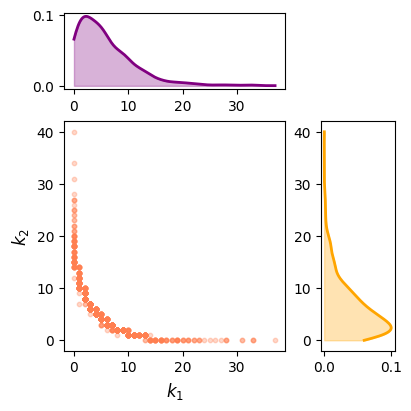

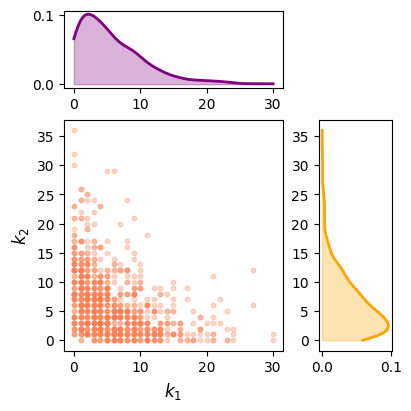

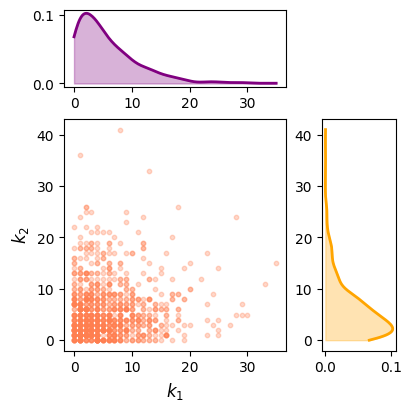

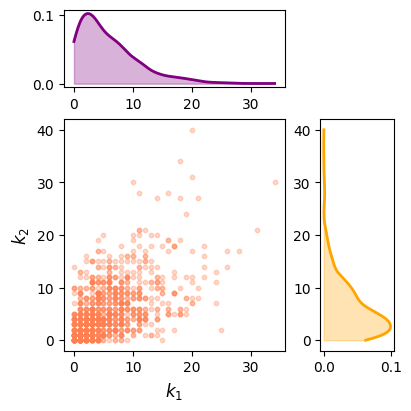

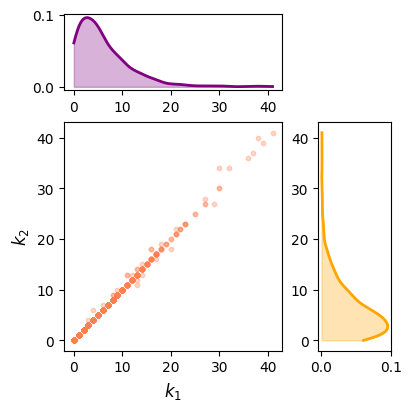

In [7]:
HO_networks=[]


#sigmas=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,1]
sigmas=[-1,-0.5,0,0.5,1]
for i in range (len(sigmas)):
    sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=sigmas[i],size=N)
    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
    HO_networks.append([hyper_edges,pairs,triples])

    ###################################################################
    from matplotlib import gridspec
    from scipy.stats import gaussian_kde
    colors=['coral','orange','purple']
    fig = plt.figure(figsize=(4, 4), constrained_layout=True)
    outer_gs = gridspec.GridSpec(1, 1, figure=fig, wspace=0.25)
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    degrees1 = np.array(list(degree_list[0].values()))
    degrees2 = np.array(list(degree_list[1].values()))
    idx=0
        # ---- Nested grid inside each panel ----
    inner_gs = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=outer_gs[idx], hspace=0.05, wspace=0.05)
    
    ax_scatter = fig.add_subplot(inner_gs[1:4, 0:3])
    ax_histx  = fig.add_subplot(inner_gs[0, 0:3], sharex=ax_scatter)
    ax_histy  = fig.add_subplot(inner_gs[1:4, 3], sharey=ax_scatter)
    
        # ---- Scatter ----
    ax_scatter.scatter(degrees1, degrees2, color=colors[0],s=10, alpha=0.3)
    ax_scatter.set_xlabel(r"$k_1$", fontsize=12)
    ax_scatter.set_ylabel(r"$k_2$", fontsize=12)
    
        # ---- KDE marginals ----
    kde_x = gaussian_kde(degrees1)
    xs = np.linspace(degrees1.min(), degrees1.max(), 200)
    dens_x = kde_x(xs)
    ax_histx.plot(xs, dens_x, color=colors[2], lw=2)
    ax_histx.fill_between(xs, 0, dens_x, color=colors[2], alpha=0.3)
    
    kde_y = gaussian_kde(degrees2)
    ys = np.linspace(degrees2.min(), degrees2.max(), 200)
    dens_y = kde_y(ys)
    ax_histy.plot(dens_y, ys, color=colors[1], lw=2)
    ax_histy.fill_betweenx(ys, 0, dens_y, color=colors[1], alpha=0.3)


0
Average k_1 = 5.82
Variance k_1 = 28.92
Maxmimum k_1 = 37
Average k_2 = 6.1
Variance k_2 = 30.22
Maxmimum k_2 = 40


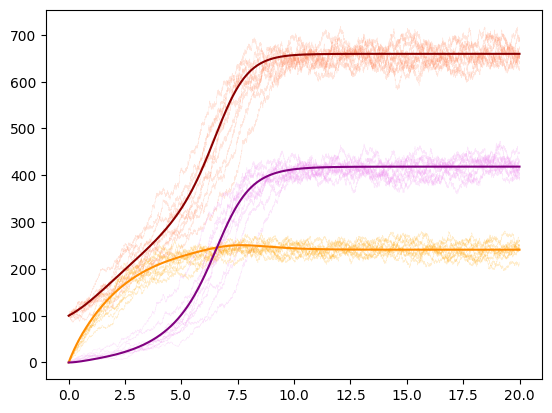

1
Average k_1 = 5.77
Variance k_1 = 25.55
Maxmimum k_1 = 30
Average k_2 = 6.09
Variance k_2 = 28.04
Maxmimum k_2 = 36


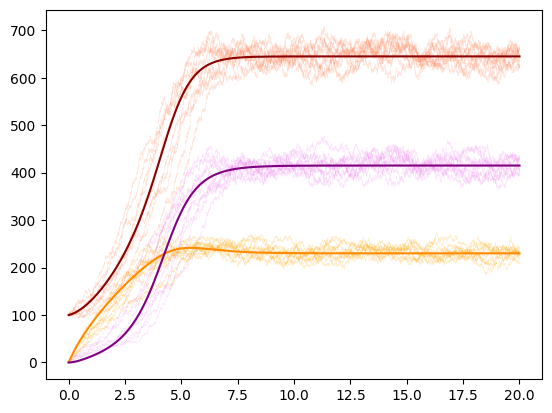

2
Average k_1 = 5.8
Variance k_1 = 28.86
Maxmimum k_1 = 35
Average k_2 = 5.73
Variance k_2 = 28.8
Maxmimum k_2 = 41


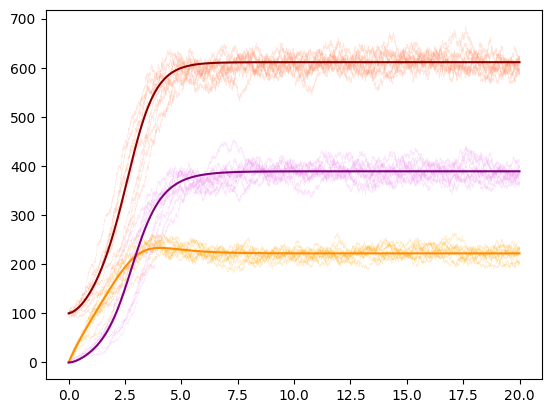

3
Average k_1 = 5.93
Variance k_1 = 26.35
Maxmimum k_1 = 34
Average k_2 = 5.88
Variance k_2 = 27.43
Maxmimum k_2 = 40


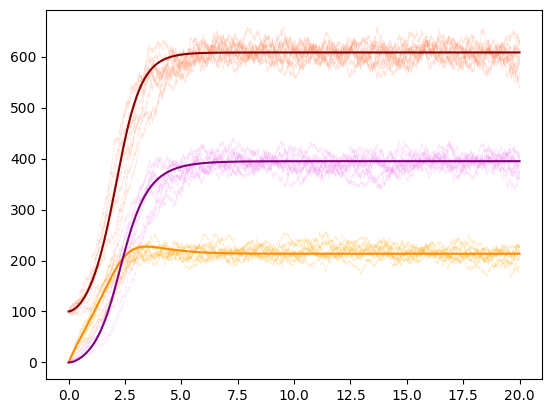

4
Average k_1 = 6.09
Variance k_1 = 32.69
Maxmimum k_1 = 41
Average k_2 = 6.11
Variance k_2 = 33.22
Maxmimum k_2 = 41


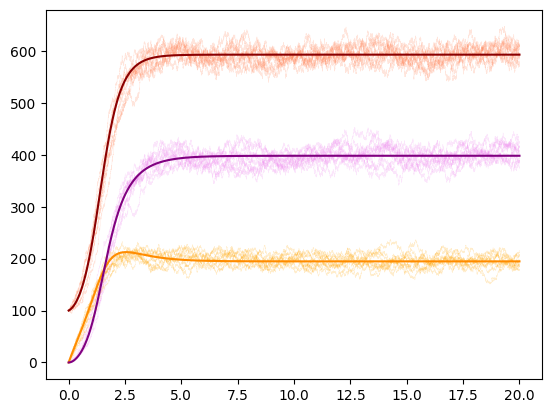

In [8]:
resutls_model_all=[]
result_sim_all=[]
lam1=1.1
lam2=2
mu=1
T=20
num_inf=30
beta1=lam1*mu/k[0]
beta2=lam2*mu/k[1]
para=[beta1,beta2,mu]

iters=10
num_inf=100
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

for i in range (len(HO_networks)):
    print(i)
    hyper_edges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    for l in range (2):
        degrees=list(degree_list[l].values())
        print(rf'Average k_{l+1} = ' + str(round(np.mean(degrees),2)))
        print(rf'Variance k_{l+1} = ' + str(round(np.var(degrees),2)))
        print(rf'Maxmimum k_{l+1} = ' + str(max(degrees)))
        
    results_=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edges,T=T,N=N,initial_infected=num_inf, steps_ode=6000)

    results_sim=[]
    for i in range (10):
        res =SIS_gillespie_HO_arrays(N=N, beta1=beta1, beta2=beta2, mu=mu,  edges=np.array(pairs), triangles=np.array(triples), init_infec=fixed_init, t_max=T,variance_threshold=1e-7)
        results_sim.append(res)


    times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total = results_
    for l in range(len(results_sim)):
        times, I, I_links, I_hyperedges, times_links, times_hyperedges = results_sim[l]
        plt.plot(times,I, color='coral', lw=0.3, alpha=0.2 )
        plt.plot(times,I_links, color='orange', lw=0.3, alpha=0.2 )
        plt.plot(times,I_hyperedges, color='violet', lw=0.3, alpha=0.2 )
    
    #ax[].plot(times,I, color='coral', lw=0.3, alpha=0.2 )
    plt.plot(times_final,I_t_final,color='darkred', label='I') 
    plt.plot(times_final,I_pair_total,color='darkorange', label='I from pair') 
    plt.plot(times_final,I_triples_total,color='purple', label='I from HO')
    plt.show()

In [9]:
prev_all_sim=[]
k1=7
k2=5
lam2=3
sigmas=[-1,-0.5,0,0.5,1]
lambdas=np.linspace(0.001,1.2,20)
iters=10
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
T=60
for i in range (0,len(HO_networks)):
    print(sigmas[i])
    hyper_edges, pairs, triples = HO_networks[i]
    prev=[]
    print('')
    
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        k.append(np.mean(degrees))
        #print(rf'Average k_{l+1} = ' + str(round(np.mean(degrees),2)))
        #print(rf'Variance k_{l+1} = ' + str(round(np.var(degrees),2)))
        #print(rf'Maxmimum k_{l+1} = ' + str(max(degrees)))
    
    for lam1 in lambdas:
        print(lam1)
        beta1=lam1*mu/k[0]
        beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        I_final=[]
        for i in range (10):
            times, I, I_links, I_hyperedges, times_links, times_hyperedges = SIS_gillespie_HO_arrays(N=N, beta1=beta1, beta2=beta2, mu=mu,  edges=np.array(pairs), triangles=np.array(triples), init_infec=fixed_init, t_max=T,variance_threshold=1e-7)
            I_final.append(np.mean(I[-100:]))
            
        prev.append(I_final)
        

    prev_all_sim.append(prev)


-1

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.8844736842105263
0.947578947368421
1.0106842105263156
1.0737894736842104
1.1368947368421052
1.2
-0.5

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.8844736842105263
0.947578947368421
1.0106842105263156
1.0737894736842104
1.1368947368421052
1.2
0

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.884473684

In [10]:
prev_all=[]
k1=7
k2=5
lam2=3
lambdas=np.linspace(0.001,1.2,20)
iters=10
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
T=100
for i in range (0,len(HO_networks)):
    print(sigmas[i])
    hyper_edges, pairs, triples = HO_networks[i]
    prev=[]
    print('')
    
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        k.append(np.mean(degrees))
        #print(rf'Average k_{l+1} = ' + str(round(np.mean(degrees),2)))
        #print(rf'Variance k_{l+1} = ' + str(round(np.var(degrees),2)))
        #print(rf'Maxmimum k_{l+1} = ' + str(max(degrees)))
    
    for lam1 in lambdas:
        beta1=lam1*mu/k[0]
        beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total  = odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edges,T=T,N=N,initial_infected=num_inf, steps_ode=20000)
        prev.append(I_t_final[-1])

    prev_all.append(prev)


-1

Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
-0.5

Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
0

Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
Infection died out, terminating early
0.5

Infection died out, terminating early
Infection died out, terminating 

prev_all2=[]
k1=7
k2=5
lam2=3
lambdas=np.linspace(0.001,1.2,20)
iters=10
num_inf=800
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
T=60
for i in range (0,len(HO_networks)):
    print(sigmas[i])
    hyper_edges, pairs, triples = HO_networks[i]
    prev=[]
    print('')
    
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        k.append(np.mean(degrees))
        #print(rf'Average k_{l+1} = ' + str(round(np.mean(degrees),2)))
        #print(rf'Variance k_{l+1} = ' + str(round(np.var(degrees),2)))
        #print(rf'Maxmimum k_{l+1} = ' + str(max(degrees)))
    
    for lam1 in lambdas:
        beta1=lam1*mu/k[0]
        beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total  = odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edges,T=T,N=N,initial_infected=num_inf, steps_ode=10000)
        prev.append(I_t_final[-1])

    prev_all2.append(prev)

In [11]:
prev_all_sim2=[]
k1=7
k2=5
lam2=3
lambdas=np.linspace(0.001,1.2,20)
iters=10
num_inf=800
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
T=60
for i in range (0,len(HO_networks)):
    print(sigmas[i])
    hyper_edges, pairs, triples = HO_networks[i]
    prev=[]
    print('')
    
    degree_list = get_degree_list_from_edges(hyper_edges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        k.append(np.mean(degrees))
        #print(rf'Average k_{l+1} = ' + str(round(np.mean(degrees),2)))
        #print(rf'Variance k_{l+1} = ' + str(round(np.var(degrees),2)))
        #print(rf'Maxmimum k_{l+1} = ' + str(max(degrees)))
    
    for lam1 in lambdas:
        print(lam1)
        beta1=lam1*mu/k[0]
        beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        I_final=[]
        for i in range (10):
            times, I, I_links, I_hyperedges, times_links, times_hyperedges = SIS_gillespie_HO_arrays(N=N, beta1=beta1, beta2=beta2, mu=mu,  edges=np.array(pairs), triangles=np.array(triples), init_infec=fixed_init, t_max=T,variance_threshold=1e-7)
            I_final.append(np.mean(I[-100:]))
            
        prev.append(I_final)
        

    prev_all_sim2.append(prev)


-1

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.8844736842105263
0.947578947368421
1.0106842105263156
1.0737894736842104
1.1368947368421052
1.2
-0.5

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.8844736842105263
0.947578947368421
1.0106842105263156
1.0737894736842104
1.1368947368421052
1.2
0

0.001
0.06410526315789473
0.12721052631578947
0.19031578947368422
0.25342105263157894
0.31652631578947366
0.37963157894736843
0.44273684210526315
0.5058421052631579
0.5689473684210526
0.6320526315789473
0.6951578947368421
0.7582631578947369
0.8213684210526315
0.884473684

In [12]:
prev_mean_sim=[]
for i in range(len(prev_all_sim)):
    prev=prev_all_sim[i]
    mean_=[]
    for ii in prev:
        if np.mean(ii)<400:
            mean_.append(0)
        else:
            mean_.append(np.mean(ii))
    prev_mean_sim.append(mean_)
print(len(prev_mean_sim[0]), len(lambdas))

20 20


In [27]:
prev_mean_sim2=[]
for i in range(len(prev_all_sim2)):
    prev=prev_all_sim2[i]
    mean_=[]
    for ii in prev:
        if np.mean(ii)<100:
            mean_.append(0)
        else:
            mean_.append(np.mean(ii))
    prev_mean_sim2.append(mean_)


In [28]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_ext = [ '#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']

k1=7
k2=5
lam2=3
sigmas=[-1,-0.5,0,0.5,1]
lambdas=np.linspace(0.001,1.2,20)

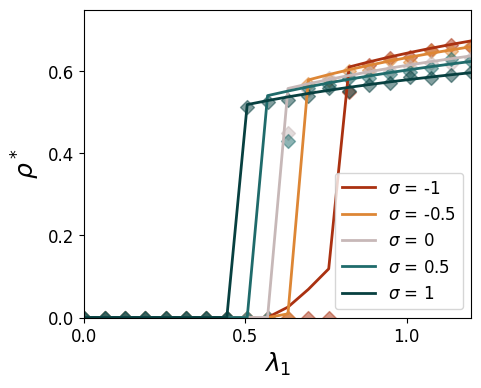

In [30]:
#colors=['firebrick', 'purple', 'darkorange']
#colors2=['skyblue', 'coral', 'orange', 'limegreen']
cmap = plt.cm.plasma  
colors = cmap(np.linspace(0, 1, 4))
colors=colors[:-1]
#colors=colors[1:-1]

plt.figure(figsize=(5, 4))
cmap = plt.cm.inferno  
#colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
lambdas =np.linspace(0.001,1.2,20)


for i in  [0,1,2,3,4]:
    plt.plot(lambdas, np.array(prev_all[i])/1000, lw=2,color=colors_1_ext[i], label=r'$\sigma$ = '+ str(sigmas[i]))

    
for i in  [0,1,2,3,4]:
    plt.scatter(lambdas, np.array(prev_mean_sim[i])/1000, color= colors_1_ext[i],marker='D', alpha=0.5, s=50)
# Add labels and title
plt.xlim((0,1.2))
plt.ylim((0,0.75))
plt.xticks(np.arange(0, 1.2, 0.5), fontsize=12)
plt.yticks(np.arange(0, 0.75, 0.2), fontsize=12)
plt.xlabel(r'$\lambda_1$', fontsize=18)
plt.ylabel(r'$\rho^*$', fontsize=18)
plt.legend(fontsize=12,loc='lower right') 
plt.savefig('4b.svg')


In [32]:
print(prev_mean_sim)

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 548.212, 613.848, 631.82, 635.0060000000001, 650.618, 664.358, 658.036], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 569.5919999999999, 578.2080000000001, 600.87, 603.756, 628.206, 623.278, 648.0219999999999, 648.2760000000001, 662.0840000000001], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 449.26800000000003, 554.8019999999999, 582.4080000000001, 586.7180000000001, 598.2259999999999, 599.956, 610.1299999999999, 620.608, 616.6479999999999, 631.53], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 429.39400000000006, 559.256, 566.0540000000001, 583.724, 584.0719999999999, 591.9499999999999, 597.464, 606.9019999999999, 629.0, 625.6580000000001], [0, 0, 0, 0, 0, 0, 0, 0, 511.966, 523.912, 529.424, 538.26, 559.23, 552.726, 567.238, 571.8679999999999, 586.3199999999999, 584.342, 591.726, 597.7959999999999]]


In [33]:
print(prev_all)

[[9.97361477733099e-09, 9.944817213234204e-09, 9.94679330626251e-09, 9.972033554186148e-09, 9.950819603663156e-09, 9.989315266676004e-09, 9.98512283272236e-09, 9.98857801236598e-09, 1.2087597049413445e-05, 0.19108531108395838, 25.398834252227903, 68.6061363177271, 118.55529779502193, 610.0335443536574, 622.7742524648265, 634.5358546042345, 645.423607743512, 655.5302038381915, 664.9369492166663, 673.7150581148181], [9.90967764504064e-09, 9.940093449289736e-09, 9.976553739198748e-09, 9.97614320117428e-09, 9.985286428697822e-09, 9.978731710526064e-09, 9.969919717395246e-09, 9.995206849629647e-09, 2.559410440515705e-07, 0.003341801632941871, 8.89186644739, 578.5865362198244, 591.493871575143, 603.4131917974328, 614.4585678706667, 624.726931906187, 634.3012816893524, 643.2531313597292, 651.64443707594, 659.5291382694825], [9.966638442367847e-09, 9.990473119649244e-09, 9.94086816245971e-09, 9.959234215781559e-09, 9.982623260773853e-09, 9.989731713606659e-09, 9.97462498372787e-09, 9.998059004

In [ ]:
np.savetxt('results/prev_5sigma.txt',prev_all)
np.savetxt('results/prev_sim_mean_5sigma.txt',prev_mean_sim)

In [ ]:
prev_all=np.loadtxt('results/prev_5sigma.txt')
prev_mean_sim = np.loadtxt('results/prev_sim_mean_5sigma.txt')

In [ ]:
#colors=['firebrick', 'purple', 'darkorange']
#colors2=['skyblue', 'coral', 'orange', 'limegreen']
cmap = plt.cm.plasma  
colors = cmap(np.linspace(0, 1, 4))
colors=colors[:-1]
#colors=colors[1:-1]

plt.figure(figsize=(4.3, 3))
cmap = plt.cm.inferno  
#colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
lambdas =np.linspace(0.001,1.2,20)


for i in  [0,1,2,3,4]:
    plt.plot(lambdas, prev_all2[i], lw=2,color=colors_1_ext[i], label=r'$\sigma$ = '+ str(sigmas[i]))

    
for i in  [0,1,2,3,4]:
    plt.scatter(lambdas, prev_mean_sim2[i], color= colors_1_ext[i],marker='D', alpha=0.5, s=50)
# Add labels and title
plt.xticks(np.arange(0, 1.2, 0.5), fontsize=12)
plt.yticks(np.arange(0, 850, 200), fontsize=12)
plt.xlabel(r'$\lambda_1$', fontsize=16)
plt.ylabel(r'$\rho$', fontsize=16)
plt.legend(fontsize=10) 

In [ ]:
#colors=['firebrick', 'purple', 'darkorange']

#colors2=['skyblue', 'coral', 'orange', 'limegreen']
cmap = plt.cm.plasma  
colors = cmap(np.linspace(0, 1, len(prev_all)+1))
colors=colors[:-1]
plt.figure(figsize=(4.3, 3))
cmap = plt.cm.inferno  
#colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
lambdas = np.linspace(0.001,2,20)

for i in range (len(HO_networks)):
    plt.plot(lambdas, prev_all[i], lw=2,color=colors[i-1], label=r'$\sigma = $' + str(sigmas[i]))

# Add labels and title
plt.xticks(np.arange(0, 2.1, 0.5), fontsize=12)
plt.yticks(np.arange(0, 850, 200), fontsize=12)
plt.xlabel(r'$\lambda_1$', fontsize=16)
plt.ylabel(r'$\rho$', fontsize=16)
plt.legend(fontsize=10) 



In [ ]:
def configurational_model_hypergraph(sample_k1,sample_k2,N):
    list_stubs=[]
    
    node_list=list(range(N))
    for i in range (len(sample_k1)):
        for k1 in range (sample_k1[i]):
            list_stubs.append(node_list[i])
    random.shuffle(list_stubs)
    edges=[]

    if len(list_stubs) % 2 != 0:
        #print('Problem with sample degree 1 ok, number of stubs must be even')
        while len(list_stubs) % 2 != 0:
            random_element = random.choice(list_stubs)
            list_stubs.remove(random_element)
        
    attempts=0
    while len(list_stubs)>0:
        attempts+=1
        if attempts>10000: 
            print('Passed max attempt')
            return 
        draw = random.sample(list_stubs, 2)
        if draw[1] != draw[0] and draw not in edges:
            #print("Draw:", draw)
            edges.append(draw)
        
        # Remove one occurrence of each drawn number
        for num in draw:
            list_stubs.remove(num)

In [ ]:
dense_HO_networks=[]
k=[6,4]
var=[30,30]
N=1000

def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

    
r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
print(r)

#sigmas=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,1]
dense_sigmas=np.linspace(-1,1,20)
for i in range (len(desne_sigmas)):
    sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=dense_sigmas[i],size=N)
    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
    dense_HO_networks.append([hyper_edges,pairs,triples])


In [ ]:
def transient_difference(I_t,I_pairs,I_triples):
    transient_I=[]
    transient_Ip=[]
    transientIt=[]
    participation=[]
    for i in range (1,len(I_t)):
        participation.append((I_pairs[i] - I_triples[i])/I_t[i])

        if i>500  and np.var(I_t[i:i+500]) < 1e-8: 
            print(I_t[i])
            break
        transient_I.append(I_t[i])
        transient_Ip.append(I_pairs[i])
        transientIt.append(I_triples[i])

    return np.mean(participation), transient_I, transient_Ip, transientIt

In [ ]:

resutls_model_all=[]
result_sim_all=[]
T=20
N=1000
num_inf=30
lam2=3
iters=60
mu=1
lambdas1=[0.7,0.9,1,1.2,1.5,2,3,4]
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
all_participations=[]

for lam1 in lambdas1:
    participation_corr=[]
    for i in range (len(dense_HO_networks)):
        k=[]
        print(i)
        hyper_edges, pairs, triples = dense_HO_networks[i]
        degree_list = get_degree_list_from_edges(hyper_edges, N=N)
        for l in range (2):
            degrees=list(degree_list[l].values())
            k.append(np.mean(degrees))
    
        beta1=lam1*mu/k[0]
        beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        participation=0
        for j in range(iters):
            results_=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edges,T=T,N=N,initial_infected=num_inf, steps_ode=6000)
            times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total = results_
        
            
            partici,  transient_I, transient_Ip, transientIt = transient_difference(I_t_final,I_pair_total,I_triples_total)
            participation+=partici
        
        participation_corr.append(participation/iters)

    all_participations.append(participation_corr)

In [ ]:
print(len(all_participations))

In [ ]:
#colors=['firebrick', 'purple', 'darkorange']
plt.figure(figsize=(4.3, 3))
 
#colors2=['skyblue', 'coral', 'orange', 'limegreen']
cmap = plt.cm.plasma  
colors = cmap(np.linspace(0, 1, len(all_participations)+1))


for i in range (2,len(all_participations)):
    plt.plot(desne_sigmas,all_participations[i], color=colors[i], label=lambdas1[i])

plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'Participation', fontsize=16)
plt.legend(fontsize=10) 
